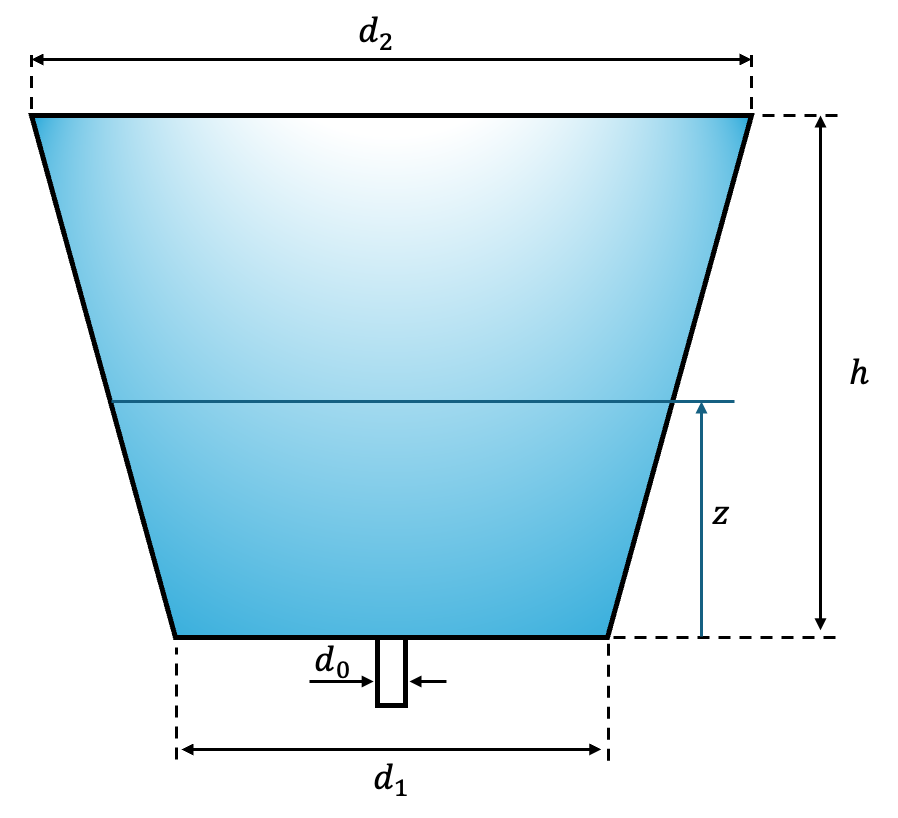

Config d0=0.01, d1=0.5, d2=1.0, h=0.2 -> initial volume V0 = 9.162979e-02 m^3
Config d0=0.01, d1=1.0, d2=0.5, h=0.2 -> initial volume V0 = 9.162979e-02 m^3


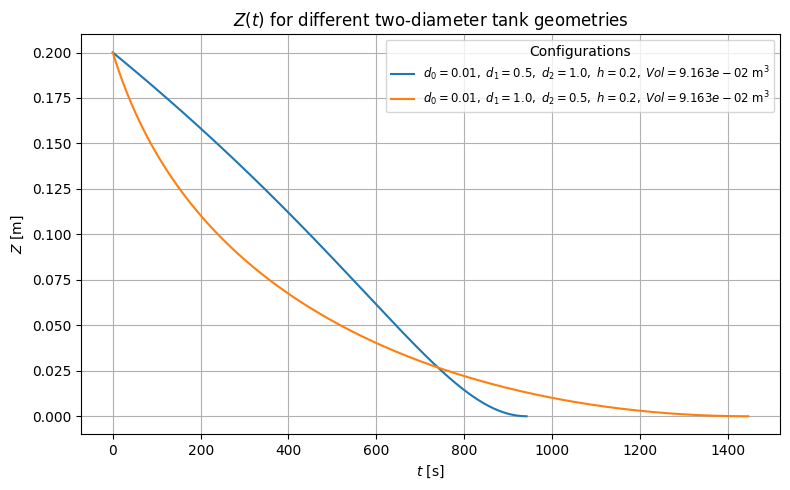

In [4]:
import math
import numpy as np
import matplotlib.pyplot as plt

# -----------------
# Configurations to compare (add or edit entries)
# Each tuple: (d0, d1, d2, h, dt)
# -----------------
configs = [
    #( d0,  d1,  d2,   h,   dt)    # dimensions in meters, dt in seconds
    (0.01, 0.5, 1.0, 0.2, 0.01),   # widening upward
    (0.01, 1.0, 0.5, 0.2, 0.01),   # narrowing upward
]

# -----------------
# Parameters (defaults, can be overridden per configuration)
# -----------------
g  = 9.81
dt = 0.01                # time step

# -----------------
# Simulation function (two-diameter linear interpolation)
# -----------------
def simulate(d0, d1, d2, h, dt=dt, g=9.81):
    A1 = math.pi * (d0 ** 2) / 4.0
    Z = [h]
    t = [0.0]
    max_steps = 1000000
    steps = 0

    while Z[-1] > 0 and steps < max_steps:
        zi = Z[-1]

        # diameter varies linearly from d1 (base, z=0) to d2 (top, z=h)
        frac = zi / h if h > 0 else 0.0
        frac = max(0.0, min(1.0, frac))
        d_z = d1 + (d2 - d1) * frac
        A2 = math.pi * (d_z ** 2) / 4.0

        den = (A2 / A1) ** 2 - 1.0

        V2 = math.sqrt(2.0 * g * zi / den)
        # From continuity A1*V1 = A2*V2 (kept for reference)
        V1 = V2 * A2 / A1

        dZ = V2 * dt
        Znew = zi - dZ
        if Znew < 0:
            Znew = 0.0

        Z.append(Znew)
        t.append(t[-1] + dt)
        steps += 1

    return np.array(t), np.array(Z)

# -----------------
# Volume helper functions (frustum / two-diameter linear tank)
# -----------------
def frustum_volume(d_base, d_top, height):
    # volume of frustum given diameters d_base (at z=0) and d_top (at z=height)
    return math.pi * height * (d_base**2 + d_base * d_top + d_top**2) / 12.0

def volume_up_to_z(z, d_base, d_top, height):
    # volume from z=0 up to z (0<=z<=height) for linearly varying diameter
    if height <= 0 or z <= 0:
        return 0.0
    k = (d_top - d_base) / height
    # V(z) = (pi/4) * (d_base^2 * z + d_base * k * z^2 + k^2 * z^3 / 3)
    return (math.pi / 4.0) * (d_base**2 * z + d_base * k * z**2 + (k**2) * z**3 / 3.0)


# -----------------
# Run simulations and plot overlays
# -----------------
plt.figure(figsize=(8,5))
for cfg in configs:
    d0_i, d1_i, d2_i, h_i, dt_i = cfg

    # compute and report initial liquid volume for this configuration
    V0 = frustum_volume(d1_i, d2_i, h_i)
    print(f"Config d0={d0_i}, d1={d1_i}, d2={d2_i}, h={h_i} -> initial volume V0 = {V0:.6e} m^3")

    t_sim, Z_sim = simulate(d0_i, d1_i, d2_i, h_i, dt=dt_i, g=g)

    # optional: compute volume history (not plotted) if you need it later
    # V_history = np.array([volume_up_to_z(z, d1_i, d2_i, h_i) for z in Z_sim])

    label = fr"$d_0={d0_i},\ d_1={d1_i},\ d_2={d2_i},\ h={h_i},\ Vol={V0:.3e}\ \mathrm{{m}}^3$"
    plt.plot(t_sim, Z_sim, label=label)

plt.xlabel(r"$t\ \mathrm{[s]}$")
plt.ylabel(r"$Z\ \mathrm{[m]}$")
plt.title(r"$Z(t)\ \text{for different two-diameter tank geometries}$")
plt.legend(title=r"Configurations", loc="best", fontsize="small")
plt.grid(True)
plt.tight_layout()
plt.show()
